In [1]:
# Import Libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
# Load Dataset
(ds_train, ds_val), ds_info = tfds.load(
    "plant_village",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features['label'].names
num_classes = ds_info.features['label'].num_classes
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.674IKF_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'T

In [7]:
IMG_SIZE = 128
BATCH_SIZE = 32
TOTAL_IMAGES = 20000

In [8]:
# Preprocessing function
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [10]:
# Take a subset of the dataset
train_subset_size = int(TOTAL_IMAGES * 0.8)
val_subset_size = TOTAL_IMAGES - train_subset_size

ds_train = ds_train.take(train_subset_size)
ds_val = ds_val.take(val_subset_size)

train = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [11]:
# Build CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train model
history = model.fit(
    train,
    epochs=20,
    validation_data=val,
    callbacks=[early_stop]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 528s 1s/step - accuracy: 0.4529 - loss: 2.0558 - val_accuracy: 0.7673 - val_loss: 0.7560
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 544s 1s/step - accuracy: 0.8009 - loss: 0.6504 - val_accuracy: 0.8085 - val_loss: 0.5976
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 500s 998ms/step - accuracy: 0.8912 - loss: 0.3433 - val_accuracy: 0.8420 - val_loss: 0.5261
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.9302 - loss: 0.2067 - val_accuracy: 0.8375 - val_loss: 0.5810
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.9513 - loss: 0.1515 - val_accuracy: 0.8645 - val_loss: 0.5328
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 555s 1s/step - accuracy: 0.9717 - loss: 0.0855 - val_accuracy: 0.8597 - val_loss: 0.5719


In [13]:
# Evaluate all metrics
eval_metrics = model.evaluate(val, verbose=0)
for name, value in zip(model.metrics_names, eval_metrics):
    print(f"{name}: {value:.4f}")

loss: 0.5261
compile_metrics: 0.8420


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


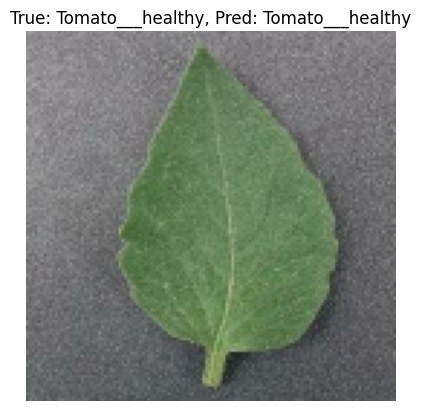

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


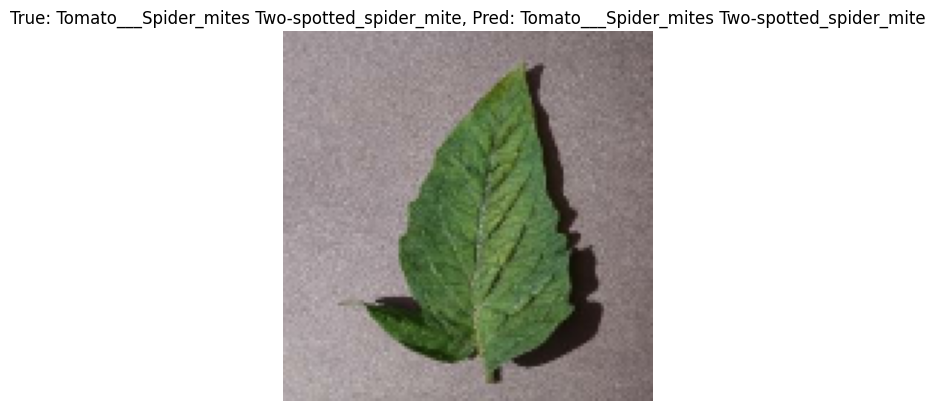

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


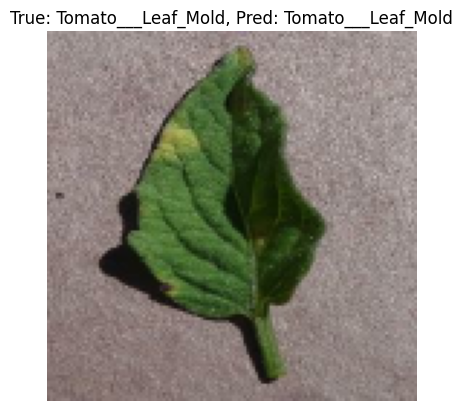

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


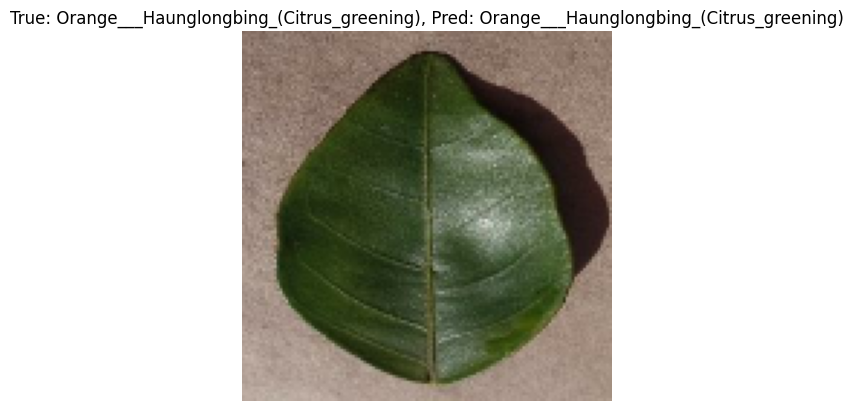

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


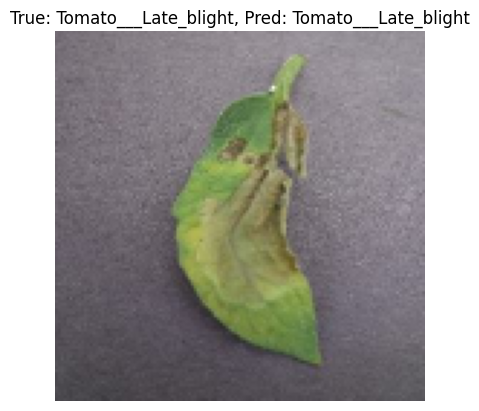

In [14]:

# Sample predictions
def show_sample_predictions(dataset, num=5):
    dataset_iter = iter(dataset.unbatch().take(num))
    for img, label in dataset_iter:
        pred = model.predict(tf.expand_dims(img, axis=0))
        pred_label = class_names[np.argmax(pred)]
        true_label = class_names[label.numpy()]
        plt.imshow(img.numpy())
        plt.title(f"True: {true_label}, Pred: {pred_label}")
        plt.axis("off")
        plt.show()

show_sample_predictions(val, num=5)

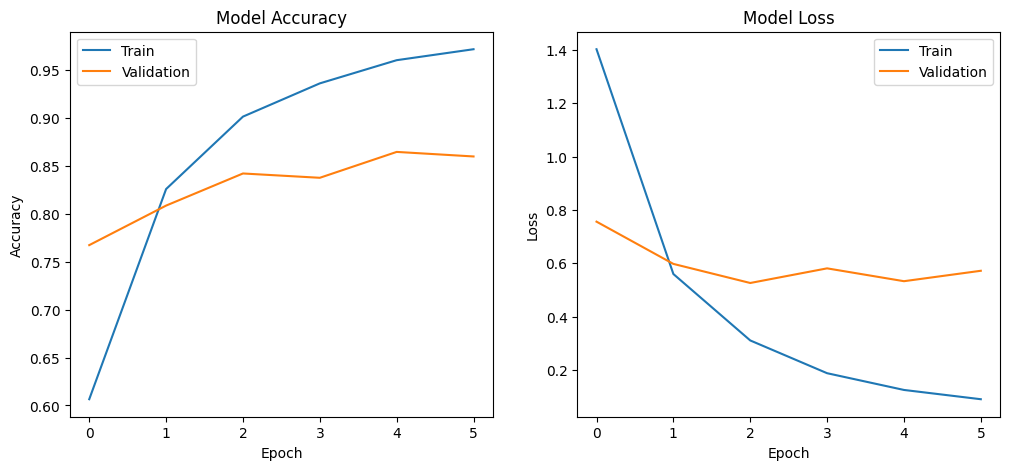

In [15]:
# Plot accuracy & loss
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()